# Titanic Dataset Analysis

## Objective
Analyze the Titanic dataset to understand survival patterns based on:
- Gender
- Passenger Class
- Age

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv


In [3]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Data Cleaning
Checking and handling missing values.

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
# Fill Age with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column
df.drop('Cabin', axis=1, inplace=True)

df.isnull().sum()

/tmp/ipykernel_2946/88684237.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_2946/88684237.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# Question 1
Who survived more: Males or Females?

In [7]:
gender_survival = df.groupby('Sex')['Survived'].mean()

print(gender_survival)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


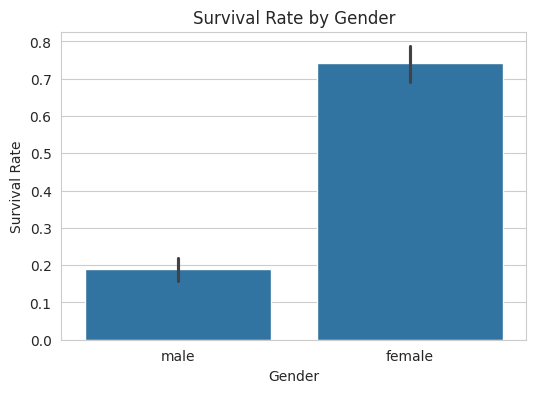

In [8]:
plt.figure(figsize=(6,4))

sns.barplot(x='Sex', y='Survived', data=df)

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')

plt.show()

# Observation

Female passengers had a significantly higher survival rate than male passengers.

# Question 2
Did passenger class affect survival chances?

In [9]:
class_survival = df.groupby('Pclass')['Survived'].mean()

print(class_survival)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


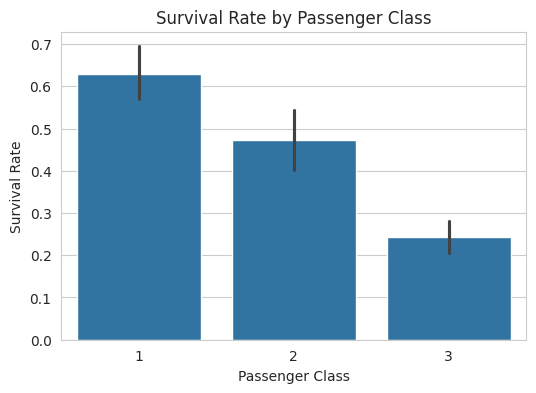

In [10]:
plt.figure(figsize=(6,4))

sns.barplot(x='Pclass', y='Survived', data=df)

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.show()

# Observation

Passengers in First Class had the highest survival rate, while Third Class passengers had the lowest.

# Question 3
What was the survival rate by age group?

In [11]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_survival = df.groupby('Age_Group')['Survived'].mean()

print(age_survival)

Age_Group
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


/tmp/ipykernel_2946/1800817433.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('Age_Group')['Survived'].mean()


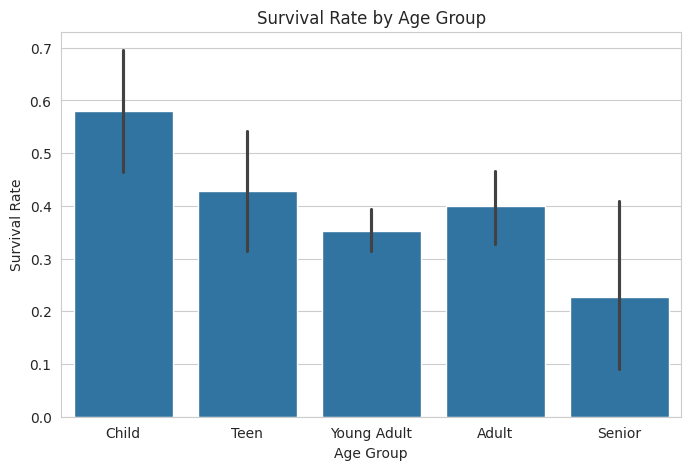

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(x='Age_Group', y='Survived', data=df)

plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')

plt.show()

# Observation

Children generally had better survival chances compared to adults and seniors.

# Passenger Age Distribution

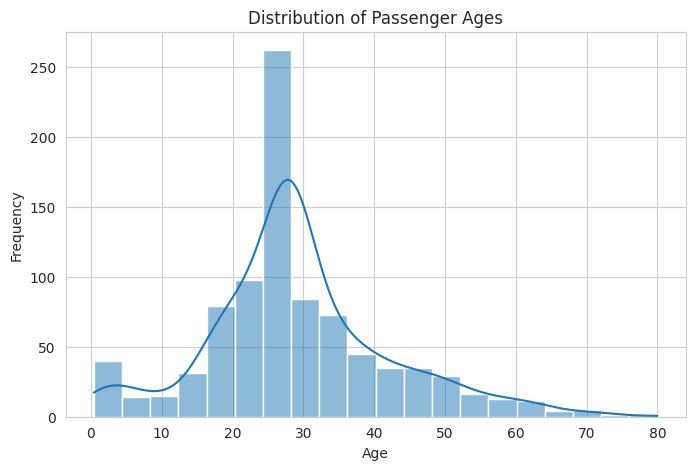

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

In [14]:
print("""
PROJECT SUMMARY

1. Females had higher survival rates than males.
2. First-class passengers survived more frequently.
3. Children had better survival chances.
4. Most passengers were young adults.

Conclusion:
Gender, passenger class, and age all influenced survival chances on the Titanic.
""")


PROJECT SUMMARY

1. Females had higher survival rates than males.
2. First-class passengers survived more frequently.
3. Children had better survival chances.
4. Most passengers were young adults.

Conclusion:
Gender, passenger class, and age all influenced survival chances on the Titanic.



# Project Summary

This project focuses on analyzing the Titanic Dataset to understand the factors that influenced passenger survival during the Titanic disaster. The dataset contains information such as passenger age, gender, ticket class, and survival status.

The analysis began with data cleaning, where missing values were identified and handled appropriately to ensure accurate results. Exploratory Data Analysis (EDA) was then performed to examine survival patterns among different groups of passengers.

Key questions addressed in this project include:
- Who had a higher survival rate: males or females?
- How did passenger class influence survival chances?
- What was the survival rate across different age groups?

Various visualizations were created using Matplotlib and Seaborn, including bar charts and histograms, to clearly present the findings. The results showed that female passengers had significantly higher survival rates than male passengers, first-class passengers were more likely to survive than those in lower classes, and children generally had better survival chances compared to adults.

Overall, this project demonstrates the importance of data cleaning, exploratory analysis, and visualization in extracting meaningful insights from real-world datasets. It also highlights how factors such as gender, age, and socio-economic status influenced survival outcomes on the Titanic.